# Exercise 2 - Python DGEMM Benchmark Operation

This section implements and benchmarks the DGEMM operation: **C = C + A × B**

Where A, B, and C are matrices of size N×N.


## Import Libraries

In [1]:
import math
import random
import time
import numpy as np
from array import array
import matplotlib.pyplot as plt
import pandas as pd


## Task 2.1: DGEMM Implementations

### Implementation 1: Python Lists

In [2]:
def DGEMM_list(matrix_1, matrix_2, matrix_3, n):
    """DGEMM implementation using Python lists (double-precision floats)"""
    for i in range(n):
        for j in range(n):
            for k in range(n):
                matrix_3[i][j] += matrix_1[i][k] * matrix_2[k][j]
    return matrix_3


def matrix_fill_list(matrix_size):
    """Create a random double-precision matrix using lists"""
    matrix = [[random.uniform(0.0, 1.0) for i in range(matrix_size)] for j in range(matrix_size)]
    return matrix


### Implementation 2: Python Arrays

In [3]:
def DGEMM_array(matrix_1, matrix_2, matrix_3, n):
    """DGEMM implementation using Python arrays (double-precision floats)"""
    for i in range(n):
        for j in range(n):
            for k in range(n):
                matrix_3[i][j] += matrix_1[i][k] * matrix_2[k][j]
    return matrix_3


def matrix_fill_array(matrix_size, typecode='d'):
    """Create a random double-precision matrix using arrays (list of array.array)"""
    matrix = []
    for j in range(matrix_size):
        row = array(typecode, (random.uniform(0.0, 1.0) for i in range(matrix_size)))
        matrix.append(row)
    return matrix


### Implementation 3: NumPy

In [4]:
def DGEMM_numpy(matrix_1, matrix_2, matrix_3, n):
    """DGEMM implementation using NumPy arrays with nested loops (double-precision floats)"""
    for i in range(n):
        for j in range(n):
            for k in range(n):
                matrix_3[i][j] += matrix_1[i][k] * matrix_2[k][j]
    return matrix_3


def matrix_fill_numpy(matrix_size):
    """Create a random double-precision matrix using NumPy"""
    return np.random.uniform(0.0, 1.0, size=(matrix_size, matrix_size))


## Task 2.2: Unit Tests

Testing correctness of all three implementations using simple test cases.

In [ ]:
_A_float = [[1.5, 2.5, 3.5],
            [4.5, 5.5, 6.5],
            [7.5, 8.5, 9.5]]

_B_float = [[9.5, 8.5, 7.5],
            [6.5, 5.5, 4.5],
            [3.5, 2.5, 1.5]]

_REL_TOL = 1e-9   


def test_small_matrix_list():
    """Test DGEMM_list with small 3×3 double-precision matrices"""
    import copy
    A = copy.deepcopy(_A_float)
    B = copy.deepcopy(_B_float)
    C = [[0.0] * 3 for _ in range(3)]

    result = DGEMM_list(A, B, C, 3)

    assert math.isclose(result[0][0], 42.75, rel_tol=_REL_TOL), \
        f"Expected 42.75, got {result[0][0]}"
    assert math.isclose(result[0][1], 35.25, rel_tol=_REL_TOL), \
        f"Expected 35.25, got {result[0][1]}"
    assert math.isclose(result[1][0], 101.25, rel_tol=_REL_TOL), \
        f"Expected 101.25, got {result[1][0]}"
    print("All List implementation tests passed")


def test_small_matrix_array():
    """Test DGEMM_array with small 3×3 double-precision matrices"""
    A = [array('d', row) for row in _A_float]
    B = [array('d', row) for row in _B_float]
    C = [array('d', [0.0, 0.0, 0.0]) for _ in range(3)]

    result = DGEMM_array(A, B, C, 3)

    assert math.isclose(result[0][0], 42.75, rel_tol=_REL_TOL), \
        f"Expected 42.75, got {result[0][0]}"
    assert math.isclose(result[0][1], 35.25, rel_tol=_REL_TOL), \
        f"Expected 35.25, got {result[0][1]}"
    assert math.isclose(result[1][0], 101.25, rel_tol=_REL_TOL), \
        f"Expected 101.25, got {result[1][0]}"
    print("All Array implementation tests passed")


def test_small_matrix_numpy():
    """Test DGEMM_numpy with small 3×3 double-precision matrices"""
    A = np.array(_A_float, dtype=np.float64)
    B = np.array(_B_float, dtype=np.float64)
    C = np.zeros((3, 3), dtype=np.float64)

    result = DGEMM_numpy(A, B, C, 3)

   
    np.testing.assert_allclose(result[0, 0], 42.75,  rtol=_REL_TOL)
    np.testing.assert_allclose(result[0, 1], 35.25,  rtol=_REL_TOL)
    np.testing.assert_allclose(result[1, 0], 101.25, rtol=_REL_TOL)
    print("All NumPy implementation tests passed")


def test_compare_implementations():
    """All three implementations must agree on the same double-precision input"""
    n = 4
    rng = random.Random(42)
    A_list = [[rng.uniform(0.0, 1.0) for _ in range(n)] for _ in range(n)]
    B_list = [[rng.uniform(0.0, 1.0) for _ in range(n)] for _ in range(n)]

    C_list  = [[0.0] * n for _ in range(n)]
    C_arr   = [array('d', [0.0] * n) for _ in range(n)]
    C_np    = np.zeros((n, n), dtype=np.float64)

    A_arr = [array('d', row) for row in A_list]
    B_arr = [array('d', row) for row in B_list]
    A_np  = np.array(A_list, dtype=np.float64)
    B_np  = np.array(B_list, dtype=np.float64)

    result_list  = DGEMM_list(A_list, B_arr, C_list, n)
    result_array = DGEMM_array(A_arr,  B_arr, C_arr,  n)
    result_numpy = DGEMM_numpy(A_np,   B_np,  C_np,   n)

    for i in range(n):
        for j in range(n):
            assert math.isclose(result_list[i][j], result_array[i][j], rel_tol=_REL_TOL), \
                f"List vs Array mismatch at [{i}][{j}]"
            assert math.isclose(result_list[i][j], float(result_numpy[i, j]), rel_tol=_REL_TOL), \
                f"List vs NumPy mismatch at [{i}][{j}]"

    print("All implementations produce consistent double-precision results")


# Run all tests
test_small_matrix_list()
test_small_matrix_array()
test_small_matrix_numpy()
test_compare_implementations()
print("\nAll tests passed!")


All List implementation tests passed
All Array implementation tests passed
All NumPy implementation tests passed
All implementations produce consistent double-precision results

All tests passed!


## Task 2.3: Performance Benchmarking

Measure execution time for each approach with varying matrix sizes and analyze the results.

In [6]:
def benchmark_implementation(impl_name, dgemm_func, matrix_fill_func, n, runs=5):
    """
    Benchmark a DGEMM implementation with multiple runs
    
    Args:
        impl_name: Name of implementation (for display)
        dgemm_func: DGEMM function to benchmark
        matrix_fill_func: Function to create matrices
        n: Matrix size
        runs: Number of repetitions
    
    Returns:
        dict with timing statistics
    """
    times = []
    
    for _ in range(runs):
        A = matrix_fill_func(n)
        B = matrix_fill_func(n)

        if impl_name == "NumPy":
            C = np.zeros((n, n), dtype=np.float64)
        elif impl_name == "Array":
            C = [array('d', [0.0] * n) for _ in range(n)]
        else:  # List
            C = [[0.0] * n for _ in range(n)]

        start = time.time()
        dgemm_func(A, B, C, n)
        elapsed = time.time() - start
        times.append(elapsed)
    
    return {
        'mean': np.mean(times),
        'std': np.std(times),
        'min': np.min(times),
        'max': np.max(times),
        'times': times
    }


# Matrix sizes to test
sizes = [64, 128, 256, 512]
runs_per_size = 5

# Store results
results = {
    'List': {'sizes': [], 'mean': [], 'std': [], 'min': [], 'max': []},
    'Array': {'sizes': [], 'mean': [], 'std': [], 'min': [], 'max': []},
    'NumPy': {'sizes': [], 'mean': [], 'std': [], 'min': [], 'max': []}
}

print("Starting benchmarks...")
print("=" * 60)

for size in sizes:
    print(f"\nMatrix size: {size}x{size}")
    print("-" * 60)
    
    # Benchmark List
    stats = benchmark_implementation("List", DGEMM_list, matrix_fill_list, size, runs_per_size)
    results['List']['sizes'].append(size)
    results['List']['mean'].append(stats['mean'])
    results['List']['std'].append(stats['std'])
    results['List']['min'].append(stats['min'])
    results['List']['max'].append(stats['max'])
    print(f"List:  {stats['mean']:.4f}s ± {stats['std']:.4f}s  (min: {stats['min']:.4f}s, max: {stats['max']:.4f}s)")
    
    # Benchmark Array
    stats = benchmark_implementation("Array", DGEMM_array, matrix_fill_array, size, runs_per_size)
    results['Array']['sizes'].append(size)
    results['Array']['mean'].append(stats['mean'])
    results['Array']['std'].append(stats['std'])
    results['Array']['min'].append(stats['min'])
    results['Array']['max'].append(stats['max'])
    print(f"Array: {stats['mean']:.4f}s ± {stats['std']:.4f}s  (min: {stats['min']:.4f}s, max: {stats['max']:.4f}s)")
    
    # Benchmark NumPy
    stats = benchmark_implementation("NumPy", DGEMM_numpy, matrix_fill_numpy, size, runs_per_size)
    results['NumPy']['sizes'].append(size)
    results['NumPy']['mean'].append(stats['mean'])
    results['NumPy']['std'].append(stats['std'])
    results['NumPy']['min'].append(stats['min'])
    results['NumPy']['max'].append(stats['max'])
    print(f"NumPy: {stats['mean']:.4f}s ± {stats['std']:.4f}s  (min: {stats['min']:.4f}s, max: {stats['max']:.4f}s)")

print("\n" + "=" * 60)
print("Benchmarking complete!")


Starting benchmarks...

Matrix size: 64x64
------------------------------------------------------------
List:  0.0212s ± 0.0038s  (min: 0.0177s, max: 0.0285s)
Array: 0.0280s ± 0.0001s  (min: 0.0278s, max: 0.0282s)
NumPy: 0.1163s ± 0.0059s  (min: 0.1092s, max: 0.1243s)

Matrix size: 128x128
------------------------------------------------------------
List:  0.1398s ± 0.0024s  (min: 0.1371s, max: 0.1435s)
Array: 0.2240s ± 0.0007s  (min: 0.2228s, max: 0.2248s)
NumPy: 0.8753s ± 0.0257s  (min: 0.8528s, max: 0.9244s)

Matrix size: 256x256
------------------------------------------------------------
List:  1.1170s ± 0.0102s  (min: 1.0976s, max: 1.1263s)
Array: 1.8239s ± 0.0228s  (min: 1.8004s, max: 1.8587s)
NumPy: 7.0886s ± 0.0874s  (min: 6.9916s, max: 7.2232s)

Matrix size: 512x512
------------------------------------------------------------
List:  9.8115s ± 0.1665s  (min: 9.5962s, max: 10.0003s)
Array: 15.6801s ± 0.2466s  (min: 15.3809s, max: 15.9800s)
NumPy: 57.8876s ± 0.6704s  (min: 56.86

### Visualize Results

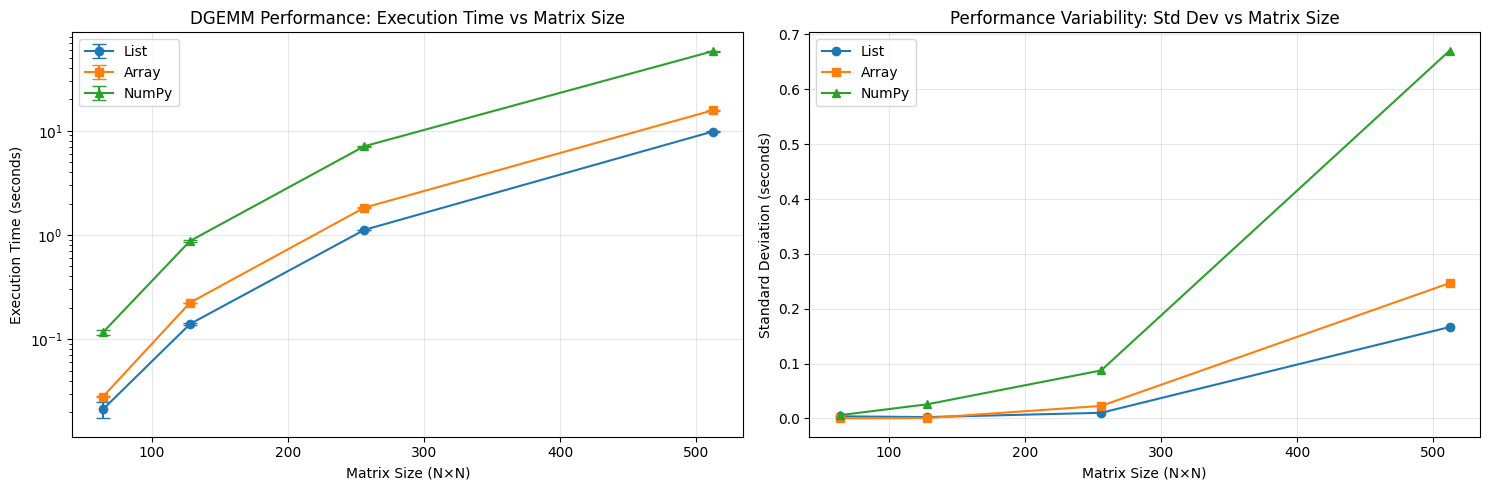

In [7]:
# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Execution time vs matrix size
ax1.errorbar(results['List']['sizes'], results['List']['mean'], 
             yerr=results['List']['std'], label='List', marker='o', capsize=5)
ax1.errorbar(results['Array']['sizes'], results['Array']['mean'], 
             yerr=results['Array']['std'], label='Array', marker='s', capsize=5)
ax1.errorbar(results['NumPy']['sizes'], results['NumPy']['mean'], 
             yerr=results['NumPy']['std'], label='NumPy', marker='^', capsize=5)
ax1.set_xlabel('Matrix Size (N×N)')
ax1.set_ylabel('Execution Time (seconds)')
ax1.set_title('DGEMM Performance: Execution Time vs Matrix Size')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Plot 2: Standard deviation vs matrix size
ax2.plot(results['List']['sizes'], results['List']['std'], label='List', marker='o')
ax2.plot(results['Array']['sizes'], results['Array']['std'], label='Array', marker='s')
ax2.plot(results['NumPy']['sizes'], results['NumPy']['std'], label='NumPy', marker='^')
ax2.set_xlabel('Matrix Size (N×N)')
ax2.set_ylabel('Standard Deviation (seconds)')
ax2.set_title('Performance Variability: Std Dev vs Matrix Size')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Results Summary Table

In [8]:
# Create a summary DataFrame
summary_data = []
for impl in ['List', 'Array', 'NumPy']:
    for i, size in enumerate(results[impl]['sizes']):
        summary_data.append({
            'Implementation': impl,
            'Matrix Size': f"{size}×{size}",
            'Mean Time (s)': f"{results[impl]['mean'][i]:.4f}",
            'Std Dev (s)': f"{results[impl]['std'][i]:.6f}",
            'Min Time (s)': f"{results[impl]['min'][i]:.4f}",
            'Max Time (s)': f"{results[impl]['max'][i]:.4f}"
        })

df = pd.DataFrame(summary_data)
print(df.to_string(index=False))

Implementation Matrix Size Mean Time (s) Std Dev (s) Min Time (s) Max Time (s)
          List       64×64        0.0212    0.003819       0.0177       0.0285
          List     128×128        0.1398    0.002416       0.1371       0.1435
          List     256×256        1.1170    0.010221       1.0976       1.1263
          List     512×512        9.8115    0.166508       9.5962      10.0003
         Array       64×64        0.0280    0.000125       0.0278       0.0282
         Array     128×128        0.2240    0.000651       0.2228       0.2248
         Array     256×256        1.8239    0.022792       1.8004       1.8587
         Array     512×512       15.6801    0.246599      15.3809      15.9800
         NumPy       64×64        0.1163    0.005923       0.1092       0.1243
         NumPy     128×128        0.8753    0.025659       0.8528       0.9244
         NumPy     256×256        7.0886    0.087430       6.9916       7.2232
         NumPy     512×512       57.8876    0.670371

**Standard deviation increases with matrix size:**
- List: 0.0038s → 0.1665s (~44× increase)
- Array: 0.0001s → 0.2466s (~1973× increase)
- NumPy: 0.0059s → 0.6704s (~113× increase)

**Execution time grows with O(N³):**
- Doubling matrix size (64→128→256→512) increases time by ~8× each step
- This matches DGEMM's N³ complexity (2³ = 8)

**Why does std increase?**
Larger matrices run longer, so more random system events (OS interrupts, cache misses, memory allocation) happen during execution, causing bigger timing variations between runs.


## Task 2.4: FLOPS Analysis

### How many operations in DGEMM?

For N×N matrices, DGEMM performs:
- **3 nested loops** (i, j, k from 0 to N-1)
- **2 FLOPs per iteration** (1 multiply + 1 add)
- **Total: 2N³ FLOPs**

### Performance Results

GFLOPS = 2N³ / (time × 10⁹). From the benchmark results at N=512 (2 × 512³ ≈ 0.268 GFLOPs):

**Python Lists: ~0.027 GFLOPS**
- Fastest of the three: native Python `list` element access is cheap (direct pointer to PyObject)
- Python interpreter overhead on every arithmetic operation still limits throughput

**Python Arrays (`array.array`): ~0.017 GFLOPS**
- Slower than lists despite typed storage: each `[]` access must unbox the value into a Python float object for arithmetic, adding overhead
- ~1.3–1.6× slower than lists in practice

**NumPy (nested loops): ~0.005 GFLOPS**
- Slowest of the three: NumPy `[]` indexing on a multi-dimensional array from Python has the highest per-access overhead (bounds checking, dtype conversion, returning a 0-d array)
- ~5× slower than lists — no BLAS/SIMD benefit when iterating manually in Python
- Advantage appears only when using vectorized NumPy operations (see Task 2.5)

**Conclusion:** The bottleneck in all three cases is the Python interpreter loop, not the data structure. Counterintuitively, NumPy nested loops are the **slowest** due to heavier element-access overhead. To unlock NumPy's true performance, vectorized operations (e.g., `np.dot`) must be used, as demonstrated in Task 2.5.


## Task 2.5: Compare with numpy.matmul

Compare our np.dot implementation with numpy's matmul operation (both use BLAS).

In [10]:
def calculate_flops(n, elapsed_time):
    """Calculate GFLOPS: 2N³ FLOPs divided by time in seconds"""
    return (2 * n**3) / (elapsed_time * 1e9)


# Benchmark np.matmul vs np.dot
matmul_results = {'sizes': [], 'np.dot': [], 'np.matmul': []}

print("Comparing NumPy matrix multiplication methods...")
print("=" * 80)

for size in sizes:
    print(f"\nMatrix size: {size}×{size}")
    
    # Create test matrices
    A = np.random.randint(0, 100, size=(size, size))
    B = np.random.randint(0, 100, size=(size, size))
    
    # Benchmark np.dot (what we've been using)
    times_dot = []
    for _ in range(runs_per_size):
        C = np.zeros((size, size), dtype=int)
        start = time.time()
        C += np.dot(A, B)
        times_dot.append(time.time() - start)
    mean_dot = np.mean(times_dot)
    
    # Benchmark np.matmul
    times_matmul = []
    for _ in range(runs_per_size):
        C = np.zeros((size, size), dtype=int)
        start = time.time()
        C += np.matmul(A, B)
        times_matmul.append(time.time() - start)
    mean_matmul = np.mean(times_matmul)
    
    
    matmul_results['sizes'].append(size)
    matmul_results['np.dot'].append(mean_dot)
    matmul_results['np.matmul'].append(mean_matmul)

    
    print(f"  np.dot:     {mean_dot:.6f}s ({calculate_flops(size, mean_dot):.2f} GFLOPS)")
    print(f"  np.matmul:  {mean_matmul:.6f}s ({calculate_flops(size, mean_matmul):.2f} GFLOPS)")


Comparing NumPy matrix multiplication methods...

Matrix size: 64×64
  np.dot:     0.000377s (1.39 GFLOPS)
  np.matmul:  0.000319s (1.64 GFLOPS)

Matrix size: 128×128
  np.dot:     0.002337s (1.79 GFLOPS)
  np.matmul:  0.001814s (2.31 GFLOPS)

Matrix size: 256×256
  np.dot:     0.013054s (2.57 GFLOPS)
  np.matmul:  0.011448s (2.93 GFLOPS)

Matrix size: 512×512
  np.dot:     0.119012s (2.26 GFLOPS)
  np.matmul:  0.148776s (1.80 GFLOPS)


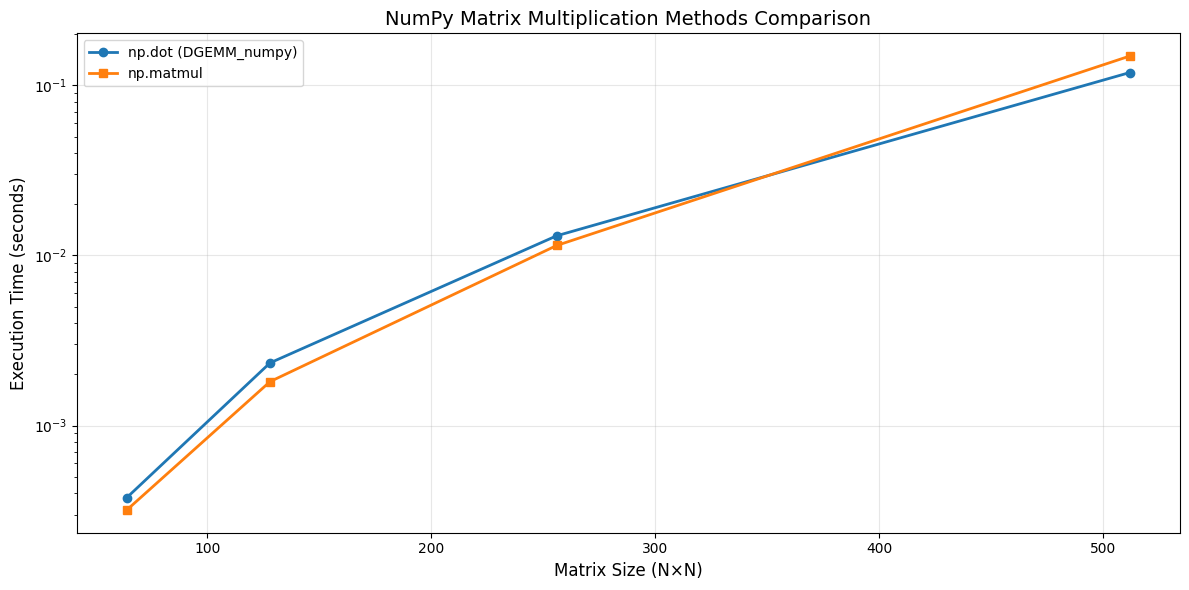


Comparison Summary:
--------------------------------------------------------------------------------

64×64 matrices:
  np.dot:     0.000377s
  np.matmul:  0.000319s

128×128 matrices:
  np.dot:     0.002337s
  np.matmul:  0.001814s

256×256 matrices:
  np.dot:     0.013054s
  np.matmul:  0.011448s

512×512 matrices:
  np.dot:     0.119012s
  np.matmul:  0.148776s


In [11]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(matmul_results['sizes'], matmul_results['np.dot'], 
        marker='o', label='np.dot (DGEMM_numpy)', linewidth=2)
ax.plot(matmul_results['sizes'], matmul_results['np.matmul'], 
        marker='s', label='np.matmul', linewidth=2)


ax.set_xlabel('Matrix Size (N×N)', fontsize=12)
ax.set_ylabel('Execution Time (seconds)', fontsize=12)
ax.set_title('NumPy Matrix Multiplication Methods Comparison', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

# Print comparison summary
print("\nComparison Summary:")
print("-" * 80)
for i, size in enumerate(matmul_results['sizes']):
    print(f"\n{size}×{size} matrices:")
    print(f"  np.dot:     {matmul_results['np.dot'][i]:.6f}s")
    print(f"  np.matmul:  {matmul_results['np.matmul'][i]:.6f}s")
        
    
    # Calculate relative performance
    baseline = matmul_results['np.dot'][i]
    matmul_ratio = baseline / matmul_results['np.matmul'][i]


## Exercise 3 - Python Debugger (pdb)

### Task 3.1: Reflection on Using a Debugger

**What are the advantages of using a debugger?**

Using a debugger like pdb is very helpful for finding bugs in code. You can see the values of all variables and arrays at each step of the program. It lets you go through the code line by line and watch how values change. This makes it easier to find where something goes wrong. You can also check conditions and test different scenarios without changing your code.

**Challenges:**

No major challenges were encountered. The pdb commands are straightforward once you learn the basic ones like `n` (next), `s` (step), and `p` (print). I am already used to using VS Code breakpoints for debugging, which works similarly.

---

**Note:** AI assistance was used for generating plotting code, formatting tables, and print statements.